In [1]:
import numpy as np
import pandas as pd

import tensorflow
from tensorflow import keras
import ml_edu.experiment
import ml_edu.results

import plotly.express as px

In [2]:
dataset = pd.read_csv('chicago_taxi_train.csv')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TRIP_START_TIMESTAMP    31694 non-null  object 
 1   TRIP_END_TIMESTAMP      31694 non-null  object 
 2   TRIP_START_HOUR         31694 non-null  float64
 3   TRIP_SECONDS            31694 non-null  int64  
 4   TRIP_MILES              31694 non-null  float64
 5   TRIP_SPEED              31694 non-null  float64
 6   PICKUP_CENSUS_TRACT     13259 non-null  float64
 7   DROPOFF_CENSUS_TRACT    14023 non-null  float64
 8   PICKUP_COMMUNITY_AREA   28477 non-null  float64
 9   DROPOFF_COMMUNITY_AREA  28199 non-null  float64
 10  FARE                    31694 non-null  float64
 11  TIPS                    31694 non-null  float64
 12  TIP_RATE                31694 non-null  float64
 13  TOLLS                   31694 non-null  float64
 14  EXTRAS                  31694 non-null

In [4]:
dataset.head()

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [5]:
training_df = dataset.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]
training_df.head()

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0


In [6]:
len(training_df.index)

31694

In [7]:
training_df.describe()

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694.000000
mean,8.289463,1319.796397,23.905210,12.965785
std,7.265672,928.932873,16.970022,15.517765
min,0.500000,60.000000,3.250000,0.000000
25%,1.720000,548.000000,9.000000,0.000000
50%,5.920000,1081.000000,18.750000,12.200000
75%,14.500000,1888.000000,38.750000,20.800000
max,68.120000,7140.000000,159.250000,648.600000


In [8]:
training_df.describe(include = 'all')

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


In [10]:
training_df.corr(numeric_only='True')

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [12]:
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])

In [13]:
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)


  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:


  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.



Epoch 1/20

634/634 [==============================] - 1s 1ms/step - loss: 1750.0315 - rmse: 41.8334
Epoch 2/20
634/634 [==============================] - 1s 958us/step - loss: 1193.1543 - rmse: 34.5421
Epoch 3/20
634/634 [==============================] - 1s 1ms/step - loss: 746.7380 - rmse: 27.3265
Epoch 4/20
634/634 [==============================] - 1s 1ms/step - loss: 406.0975 - rmse: 20.1519
Epoch 5/20
634/634 [==============================] - 1s 943us/step - loss: 172.7198 - rmse: 13.1423
Epoch 6/20
634/634 [==============================] - 1s 947us/step - loss: 45.6441 - rmse: 6.7560
Epoch 7/20
634/634 [==============================] - 1s 949us/step - loss: 14.7382 - rmse: 3.8390
Epoch 8/20
634/634 [==============================] - 1s 984us/step - loss: 14.2484 - rmse: 3.7747
Epoch 9/20
634/634 [==============================] - 1s 903us/step - loss: 14.1230 - rmse: 3.7581
Epoch 10/20
634/634 [==============================] - 1s 1ms/step - loss: 14.0698 - rmse: 3.7510
Epo

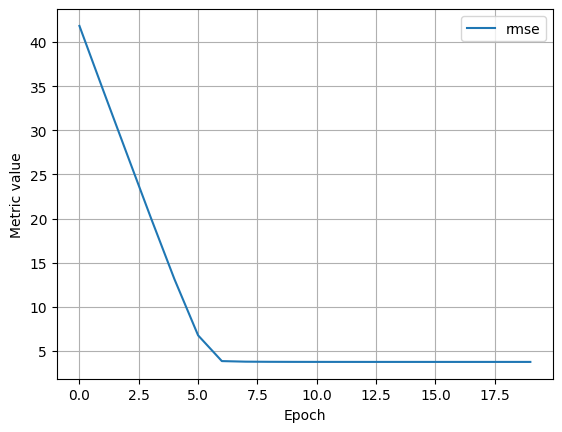

In [14]:
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')

Epoch 1/20
634/634 [==============================] - 1s 922us/step - loss: 460.8461 - rmse: 21.4673
Epoch 2/20
634/634 [==============================] - 1s 895us/step - loss: 209.4717 - rmse: 14.4731
Epoch 3/20
634/634 [==============================] - 1s 1ms/step - loss: 63.5462 - rmse: 7.9716
Epoch 4/20
634/634 [==============================] - 1s 1ms/step - loss: 18.6852 - rmse: 4.3226
Epoch 5/20
634/634 [==============================] - 1s 955us/step - loss: 16.2918 - rmse: 4.0363
Epoch 6/20
634/634 [==============================] - 1s 846us/step - loss: 15.3783 - rmse: 3.9215
Epoch 7/20
634/634 [==============================] - 1s 947us/step - loss: 14.7499 - rmse: 3.8406
Epoch 8/20
634/634 [==============================] - 1s 972us/step - loss: 14.3928 - rmse: 3.7938
Epoch 9/20
634/634 [==============================] - 1s 929us/step - loss: 14.1987 - rmse: 3.7681
Epoch 10/20
634/634 [==============================] - 1s 965us/step - loss: 14.1027 - rmse: 3.7554
Epoch 11/

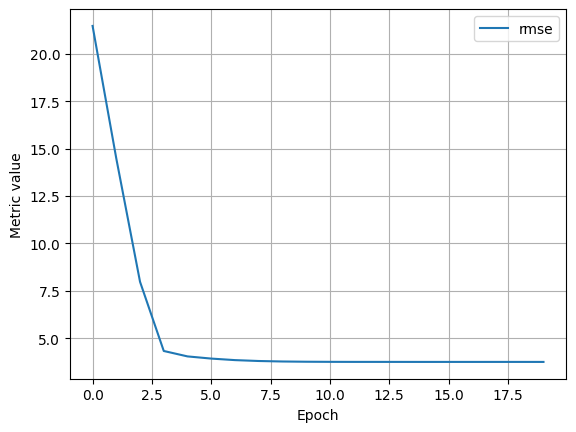

In [16]:
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature_hyper', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 [==============================] - 1s 1ms/step - loss: 182.5388 - rmse: 13.5107
Epoch 2/20
634/634 [==============================] - 1s 1ms/step - loss: 128.9663 - rmse: 11.3563
Epoch 3/20
634/634 [==============================] - 1s 2ms/step - loss: 88.7245 - rmse: 9.4194
Epoch 4/20
634/634 [==============================] - 1s 1ms/step - loss: 56.7396 - rmse: 7.5326
Epoch 5/20
634/634 [==============================] - 1s 1ms/step - loss: 34.5027 - rmse: 5.8739
Epoch 6/20
634/634 [==============================] - 1s 2ms/step - loss: 20.9292 - rmse: 4.5748
Epoch 7/20
634/634 [==============================] - 1s 1ms/step - loss: 14.9749 - rmse: 3.8697
Epoch 8/20
634/634 [==============================] - 1s 1ms/step - loss: 13.0566 - rmse: 3.6134
Epoch 9/20
634/634 [==============================] - 1s 1ms/step - loss: 12.5302 - rmse: 3.5398
Epoch 10/20
634/634 [==============================] - 1s 1ms/step - loss: 12.2994 - rmse: 3.5070
Epoch 11/20
634/634 [====

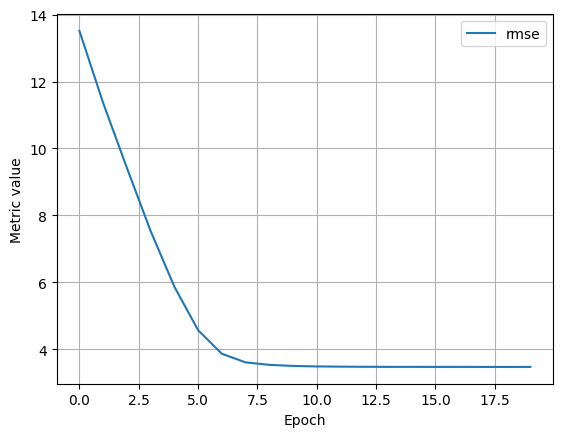

In [17]:
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS']/60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_features', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')

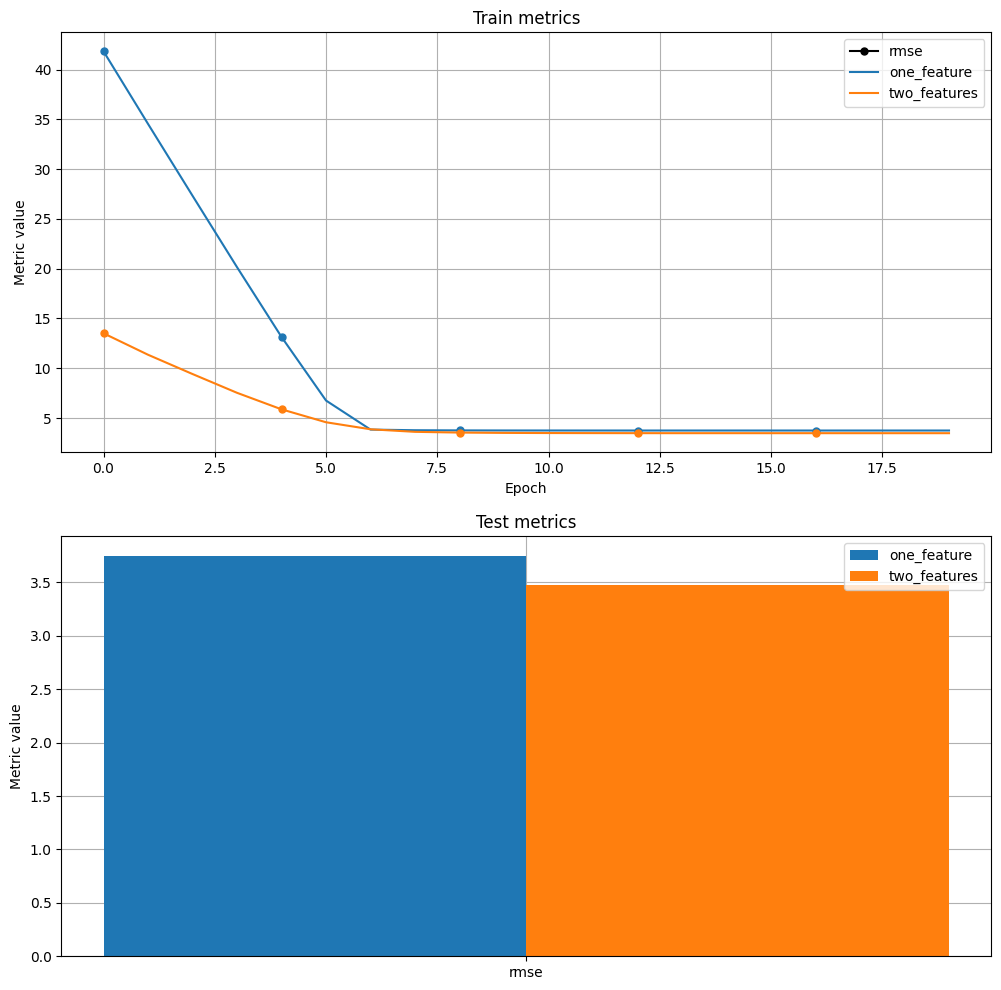

In [18]:
ml_edu.results.compare_experiment([experiment_1, experiment_3], ['rmse'], training_df, training_df['FARE'].values)

In [19]:
def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df, batch_size):
  batch = df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size), inplace=True)
  return batch

def predict_fare(model, df, features, label, batch_size=50):
  batch = build_batch(df, batch_size)
  predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})

  data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [],
          features[0]: [], features[1]: []}
  for i in range(batch_size):
    predicted = predicted_values[i][0]
    observed = batch.at[i, label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed - predicted)))
    data[features[0]].append(batch.at[i, features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))

  output_df = pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header = "-" * 80
  banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
  print(banner)
  print(output)
  return

In [20]:
output = predict_fare(experiment_3.model, training_df, experiment_3.settings.input_features, 'FARE')
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0           $7.68         $6.25   $1.43        1.35         7.72
1          $33.16        $33.00   $0.16       12.74        23.80
2           $6.56         $6.50   $0.06        0.73         8.68
3           $8.20         $7.50   $0.70        1.55         8.52
4           $6.54         $6.00   $0.54        0.91         6.02
5          $10.07        $10.20   $0.13        2.56         7.22
6          $21.96        $22.25   $0.29        7.50        20.00
7          $45.86        $44.25   $1.61       17.90        39.00
8           $8.32         $7.75   $0.57        1.54         9.45
9          $10.49         $9.50   $0.99        2.65         8.90
10          $6.05         $6.00   $0.05   